In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.4 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import re
import jieba
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import jieba.posseg as psg
from gensim.models import KeyedVectors
from matplotlib import pyplot as plt
from bertopic import BERTopic
import numpy as np
from umap import UMAP
from hdbscan import HDBSCAN

In [ ]:
!pip install gdown

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1i48SXwA2-KR_uyA1EaIy9Teo-zpnrhdE

Retrieving folder contents
Processing file 1xsfIi_E8VJFKz_W27MjSJmAVXS3g5DoP sgns.wiki.bigram
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1xsfIi_E8VJFKz_W27MjSJmAVXS3g5DoP
From (redirected): https://drive.google.com/uc?id=1xsfIi_E8VJFKz_W27MjSJmAVXS3g5DoP&confirm=t&uuid=6e9b5fb1-2ac0-4a1b-b3dc-1e51636adf1b
To: /content/Chinese-Wiki-Pretrained/sgns.wiki.bigram
100% 1.01G/1.01G [00:12<00:00, 81.1MB/s]
Download completed


## **BERTopic for Chinese data**

In [ ]:
Chinese_df = pd.read_excel("/content/lifelong learning_Chinese.xlsx")

# delate the NA abstracts
Chinese_df.dropna(subset=['摘要'], inplace=True)

# delete rows where the character numbers are less than 15.
for index, row in Chinese_df.iterrows():
    if len(row["摘要"]) < 15:
        Chinese_df.drop(index, inplace=True)

# reset the index
Chinese_df.reset_index(drop=True, inplace=True)

Chinese_df.head(5)

,来源库,题名,作者,单位,文献来源,摘要,发表时间,年份
0,期刊,教育未来发展新趋势：迈向新人文主义的终身教育——基于联合国教科文组织前瞻性教育报告,李兴洲;徐莉;姬冰澌;,北京师范大学教育学部;河北师范大学教育学院;,清华大学教育研究,有“思想实验室”之美誉的联合国教科文组织向来以积极探索和引领人类教育前瞻性发展为己任，自20...,2023-06-20,2023
1,期刊,5G+AI:终身学习发展的新动力、新范式和新实践,钱小龙;张奕潇;,南通大学教育科学学院;,成人教育,面对党和国家完善全民终身学习体系的迫切要求，5G+AI能够扮演至关重要的角色。AI能够让提供...,2023-06-05,2023
2,期刊,欧盟成人终身学习的现状、路径与镜鉴——《欧洲成人教育和培训：构建通往技能和资格的包容性途径》...,张雪翠;卢俊林;,南宁师范大学;广西物资学校;,成人教育,终身学习是助力社会和经济进步的直接动力。欧洲联盟委员会于2021年8月发布的《欧洲成人教育和...,2023-06-05,2023
3,期刊,数字化转型助推欧盟公民终身学习能力框架：要素、实践与思考,兰国帅;黄春雨;杜水莲;李晴文;郭天雯;蔡帆帆;,河南大学教育学部;河南省教育信息化发展研究中心;温州职业技术学院瑞安学院;,开放教育研究,探明高等教育数字化转型中公民终身学习能力框架及其实践，有助于丰富高等教育数字化转型理论，促进...,2023-05-25,2023
4,期刊,OECD参与全球终身学习治理：时代轨迹、行动路径与现实影响,刘海燕;,华东师范大学教育学部教育学系;,现代远程教育研究,在经济全球化和科学技术快速发展的交叠影响下，终身学习成为一种迎接挑战的全球共识和有力举措。O...,2023-05-24,2023


In [ ]:
# input stopwords
stop_file = "/content/Chinese_stopwords.txt"

stopword_list = []
# read the stopwords.txt file
with open(stop_file, 'r', encoding='utf-8') as file:
    # read stopwords and save into the list
    for line in file:
        stopword_list.append(line.strip())  # delete empty symbols

# create the predicted topics for LDA
predict_topic_csv_path = 'topic-distribution.csv'

In [ ]:
Chinese_df['摘要'] = Chinese_df['摘要'].astype(str)   # transfer 'Abstract' into strings

# define a function to remove stopwords
def clean_text(text):
  words = jieba.lcut(text)
  words = [w for w in words if w not in stopword_list]
  return ' '.join(words)

Chinese_df["Contents"] = Chinese_df["摘要"].apply(clean_text)

Chinese_df["Contents"].head(5)

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.931 seconds.
DEBUG:jieba:Loading model cost 0.931 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


,Contents
0,思想 实验室 美誉 联合国教科文组织 向来 积极探索 引领 人类 前瞻性 己任 ， 20 世...
1,面对 党和国家 全民 迫切要求 ， 5G + AI 扮演 至关重要 角色 。 AI 5G 网...
2,助力 经济 动力 。 欧洲联盟 委员会 2021 年 8 月 发布 《 欧洲 成人教育 培训...
3,探明 高等教育 数字化 转型 中 公民 能力 框架 实践 ， 有助于 高等教育 数字化 转型...
4,经济 全球化 科学技术 快速 交叠 影响 下 ， 一种 迎接挑战 全球 共识 举措 。 OE...


In [ ]:
def chinese_word_cut(mytext):
    flag_list = ['a','ag','an','b','d','dg','h','i','j','l','n','ng','nr','nrfg','nrt','ns','nt','nz','r','rg','rr','rz','t','tg','vn']

    word_list = []

    #jieba tokenization
    seg_list = psg.cut(mytext)
    for seg_word in seg_list:
        word = re.sub(u'[^\u4e00-\u9fa5]','',seg_word.word)
        if seg_word.flag in flag_list:
            word_list.append(word)
    return (" ").join(word_list)

Chinese_df["Chinese_cutted"] = Chinese_df["Contents"].apply(chinese_word_cut)

Chinese_df["Chinese_cutted"]

,Chinese_cutted
0,思想 实验室 美誉 联合国教科文组织 积极探索 人类 前瞻性 己任 世纪 年代 陆续 学会 ...
1,党和国家 全民 迫切要求 至关重要 角色 网络 设备 更 驱动 体验 更 完美 时代 技术 ...
2,助力 经济 动力 欧洲联盟 委员会 欧洲 成人教育 培训 通往 技能 资格 包容性 途径 报...
3,高等教育 数字化 转型 公民 能力 框架 高等教育 数字化 转型 理论 高等教育 现代化 理...
4,经济 全球化 科学技术 快速 影响 迎接挑战 全球 共识 全球 参与者 领域 地位 日益 凸...
...,...
2091,服务 社会主义 现代化 建设 传统 董明传 成人教育 形势 今后任务 成人教育 情况 青壮年...
2092,成人教育 传统 学校 新型 制度 上海市 建设 学院 理想 更新 技能 机会 院校 该院 原...
2093,概念 联合国教科文组织 富尔 报告 洛比 曾 定义 现行 制度 重组 制度 计划 学员 态度...
2094,近 国际 新兴 理论 本世纪 后半期 科学技术 生活 变化 环境 变化 新 课题 新 课题 ...


In [ ]:
# import the pre-trained word2vec model (here we use the Chinese-Wiki pretrained model)

chinese_pretrained_model = KeyedVectors.load_word2vec_format('/content/Chinese-Wiki-Pretrained/sgns.wiki.bigram', unicode_errors='ignore')
chinese_pretrained_model

In [ ]:
topic_model = BERTopic(
    language='chinese(simplified)',
    embedding_model=chinese_pretrained_model,
    calculate_probabilities=True,
    nr_topics=20,
    verbose=True)

In [ ]:
# convert dataframe into a list
docs = Chinese_df["Chinese_cutted"].astype(str).tolist()


In [ ]:
# prepare tokenized documents
tokenized_docs = [d.split() for d in docs]
dictionary = Dictionary(tokenized_docs)

def get_topic_words(model, top_n=20):
    topics = model.get_topics()
    return [[w for w, _ in topics[t][:top_n]] for t in topics if t != -1]

def coherence_cv(model, tokenized_docs, dictionary, top_n=20):
    tw = get_topic_words(model, top_n=top_n)
    if not tw:
        return np.nan
    cm = CoherenceModel(
        topics=tw,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

# 2) sweep min_topic_size
results = {
    "min_topic_size": [],
    "n_topics": [],
    "outlier_rate": [],
    "coherence_cv": []
}

for m in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]:

    umap_model = UMAP(n_neighbors=100, n_components=10, min_dist=0.0, metric='cosine')

    hdbscan_tuned = HDBSCAN(
        min_cluster_size=m,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    topic_model_m = BERTopic(
        language='chinese(simplified)',
        embedding_model=chinese_pretrained_model,
        calculate_probabilities=True,
        nr_topics=20,
        verbose=True)

    topics, _ = topic_model_m.fit_transform(docs)

    # Metrics
    n_topics = len(set(t for t in topics if t != -1))
    outlier_rate = float(np.mean(np.array(topics) == -1))
    c_v = coherence_cv(topic_model_m, tokenized_docs, dictionary, top_n=20)

    results["min_topic_size"].append(m)
    results["n_topics"].append(n_topics)
    results["outlier_rate"].append(outlier_rate)
    results["coherence_cv"].append(c_v)
    print(f"min_topic_size={m:>3} | topics={n_topics:>3} | outliers={outlier_rate:>5.2%} | c_v={c_v:.4f}")

# 3) results
for m, k, o, cv in zip(results["min_topic_size"], results["n_topics"], results["outlier_rate"], results["coherence_cv"]):
    print(f"min_topic_size={m:>3} | topics={k:>3} | outliers={o:>5.2%} | c_v={cv:.4f}")


2025-10-18 20:34:25,845 - BERTopic - Embedding - Transforming documents to embeddings.
100%|██████████| 2096/2096 [00:00<00:00, 8100.92it/s]
2025-10-18 20:34:26,135 - BERTopic - Embedding - Completed ✓
2025-10-18 20:34:26,136 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-18 20:34:48,882 - BERTopic - Dimensionality - Completed ✓
2025-10-18 20:34:48,883 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-18 20:34:49,208 - BERTopic - Cluster - Completed ✓
2025-10-18 20:34:49,209 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-18 20:34:49,338 - BERTopic - Representation - Completed ✓
2025-10-18 20:34:49,339 - BERTopic - Topic reduction - Reducing number of topics
2025-10-18 20:34:49,358 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-18 20:34:49,447 - BERTopic - Representation - Completed ✓
2025-10-18 20:34:49,450 - BERTopic - Topic reduction - Reduced

min_topic_size=  2 | topics= 19 | outliers=36.83% | c_v=0.4773


100%|██████████| 2096/2096 [00:00<00:00, 9008.34it/s]
2025-10-18 20:34:50,204 - BERTopic - Embedding - Completed ✓
2025-10-18 20:34:50,206 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-18 20:35:00,288 - BERTopic - Dimensionality - Completed ✓
2025-10-18 20:35:00,290 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-18 20:35:00,785 - BERTopic - Cluster - Completed ✓
2025-10-18 20:35:00,787 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-18 20:35:00,999 - BERTopic - Representation - Completed ✓
2025-10-18 20:35:01,001 - BERTopic - Topic reduction - Reducing number of topics
2025-10-18 20:35:01,029 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-18 20:35:01,272 - BERTopic - Representation - Completed ✓
2025-10-18 20:35:01,277 - BERTopic - Topic reduction - Reduced number of topics from 42 to 20
2025-10-18 20:35:02,119 - BERTopic - Embedding - Transf

min_topic_size=  3 | topics= 19 | outliers=41.56% | c_v=0.5019


100%|██████████| 2096/2096 [00:00<00:00, 11098.10it/s]
2025-10-18 20:35:02,325 - BERTopic - Embedding - Completed ✓
2025-10-18 20:35:02,326 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-18 20:35:11,309 - BERTopic - Dimensionality - Completed ✓
2025-10-18 20:35:11,311 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-18 20:35:11,602 - BERTopic - Cluster - Completed ✓
2025-10-18 20:35:11,604 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-18 20:35:11,732 - BERTopic - Representation - Completed ✓
2025-10-18 20:35:11,733 - BERTopic - Topic reduction - Reducing number of topics
2025-10-18 20:35:11,747 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-18 20:35:11,871 - BERTopic - Representation - Completed ✓
2025-10-18 20:35:11,876 - BERTopic - Topic reduction - Reduced number of topics from 42 to 20
2025-10-18 20:35:12,576 - BERTopic - Embedding - Trans

...

min_topic_size= 19 | topics= 19 | outliers=37.45% | c_v=0.4755


100%|██████████| 2096/2096 [00:00<00:00, 11247.08it/s]
2025-10-18 20:38:10,406 - BERTopic - Embedding - Completed ✓
2025-10-18 20:38:10,407 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-18 20:38:21,357 - BERTopic - Dimensionality - Completed ✓
2025-10-18 20:38:21,358 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-18 20:38:21,665 - BERTopic - Cluster - Completed ✓
2025-10-18 20:38:21,667 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-18 20:38:21,790 - BERTopic - Representation - Completed ✓
2025-10-18 20:38:21,792 - BERTopic - Topic reduction - Reducing number of topics
2025-10-18 20:38:21,809 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-18 20:38:21,940 - BERTopic - Representation - Completed ✓
2025-10-18 20:38:21,944 - BERTopic - Topic reduction - Reduced number of topics from 43 to 20
2025-10-18 20:38:22,460 - BERTopic - Embedding - Trans

min_topic_size= 20 | topics= 19 | outliers=38.41% | c_v=0.4545


100%|██████████| 2096/2096 [00:00<00:00, 9201.71it/s]
2025-10-18 20:38:22,703 - BERTopic - Embedding - Completed ✓
2025-10-18 20:38:22,706 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-18 20:38:33,400 - BERTopic - Dimensionality - Completed ✓
2025-10-18 20:38:33,401 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-18 20:38:33,706 - BERTopic - Cluster - Completed ✓
2025-10-18 20:38:33,707 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-18 20:38:33,829 - BERTopic - Representation - Completed ✓
2025-10-18 20:38:33,830 - BERTopic - Topic reduction - Reducing number of topics
2025-10-18 20:38:33,845 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-18 20:38:33,970 - BERTopic - Representation - Completed ✓
2025-10-18 20:38:33,975 - BERTopic - Topic reduction - Reduced number of topics from 43 to 20


min_topic_size= 21 | topics= 19 | outliers=32.49% | c_v=0.4816
min_topic_size=  2 | topics= 19 | outliers=36.83% | c_v=0.4773
min_topic_size=  3 | topics= 19 | outliers=41.56% | c_v=0.5019
min_topic_size=  4 | topics= 19 | outliers=36.07% | c_v=0.4827
min_topic_size=  5 | topics= 19 | outliers=37.60% | c_v=0.4656
min_topic_size=  6 | topics= 19 | outliers=38.98% | c_v=0.4937
min_topic_size=  7 | topics= 19 | outliers=36.35% | c_v=0.4584
min_topic_size=  8 | topics= 19 | outliers=38.65% | c_v=0.4879
min_topic_size=  9 | topics= 19 | outliers=33.68% | c_v=0.4943
min_topic_size= 10 | topics= 19 | outliers=38.07% | c_v=0.4745
min_topic_size= 11 | topics= 19 | outliers=36.83% | c_v=0.4669
min_topic_size= 12 | topics= 19 | outliers=36.07% | c_v=0.5023
min_topic_size= 13 | topics= 19 | outliers=35.54% | c_v=0.4667
min_topic_size= 14 | topics= 19 | outliers=36.69% | c_v=0.5094
min_topic_size= 15 | topics= 19 | outliers=35.07% | c_v=0.4843
min_topic_size= 16 | topics= 19 | outliers=34.06% | c_v

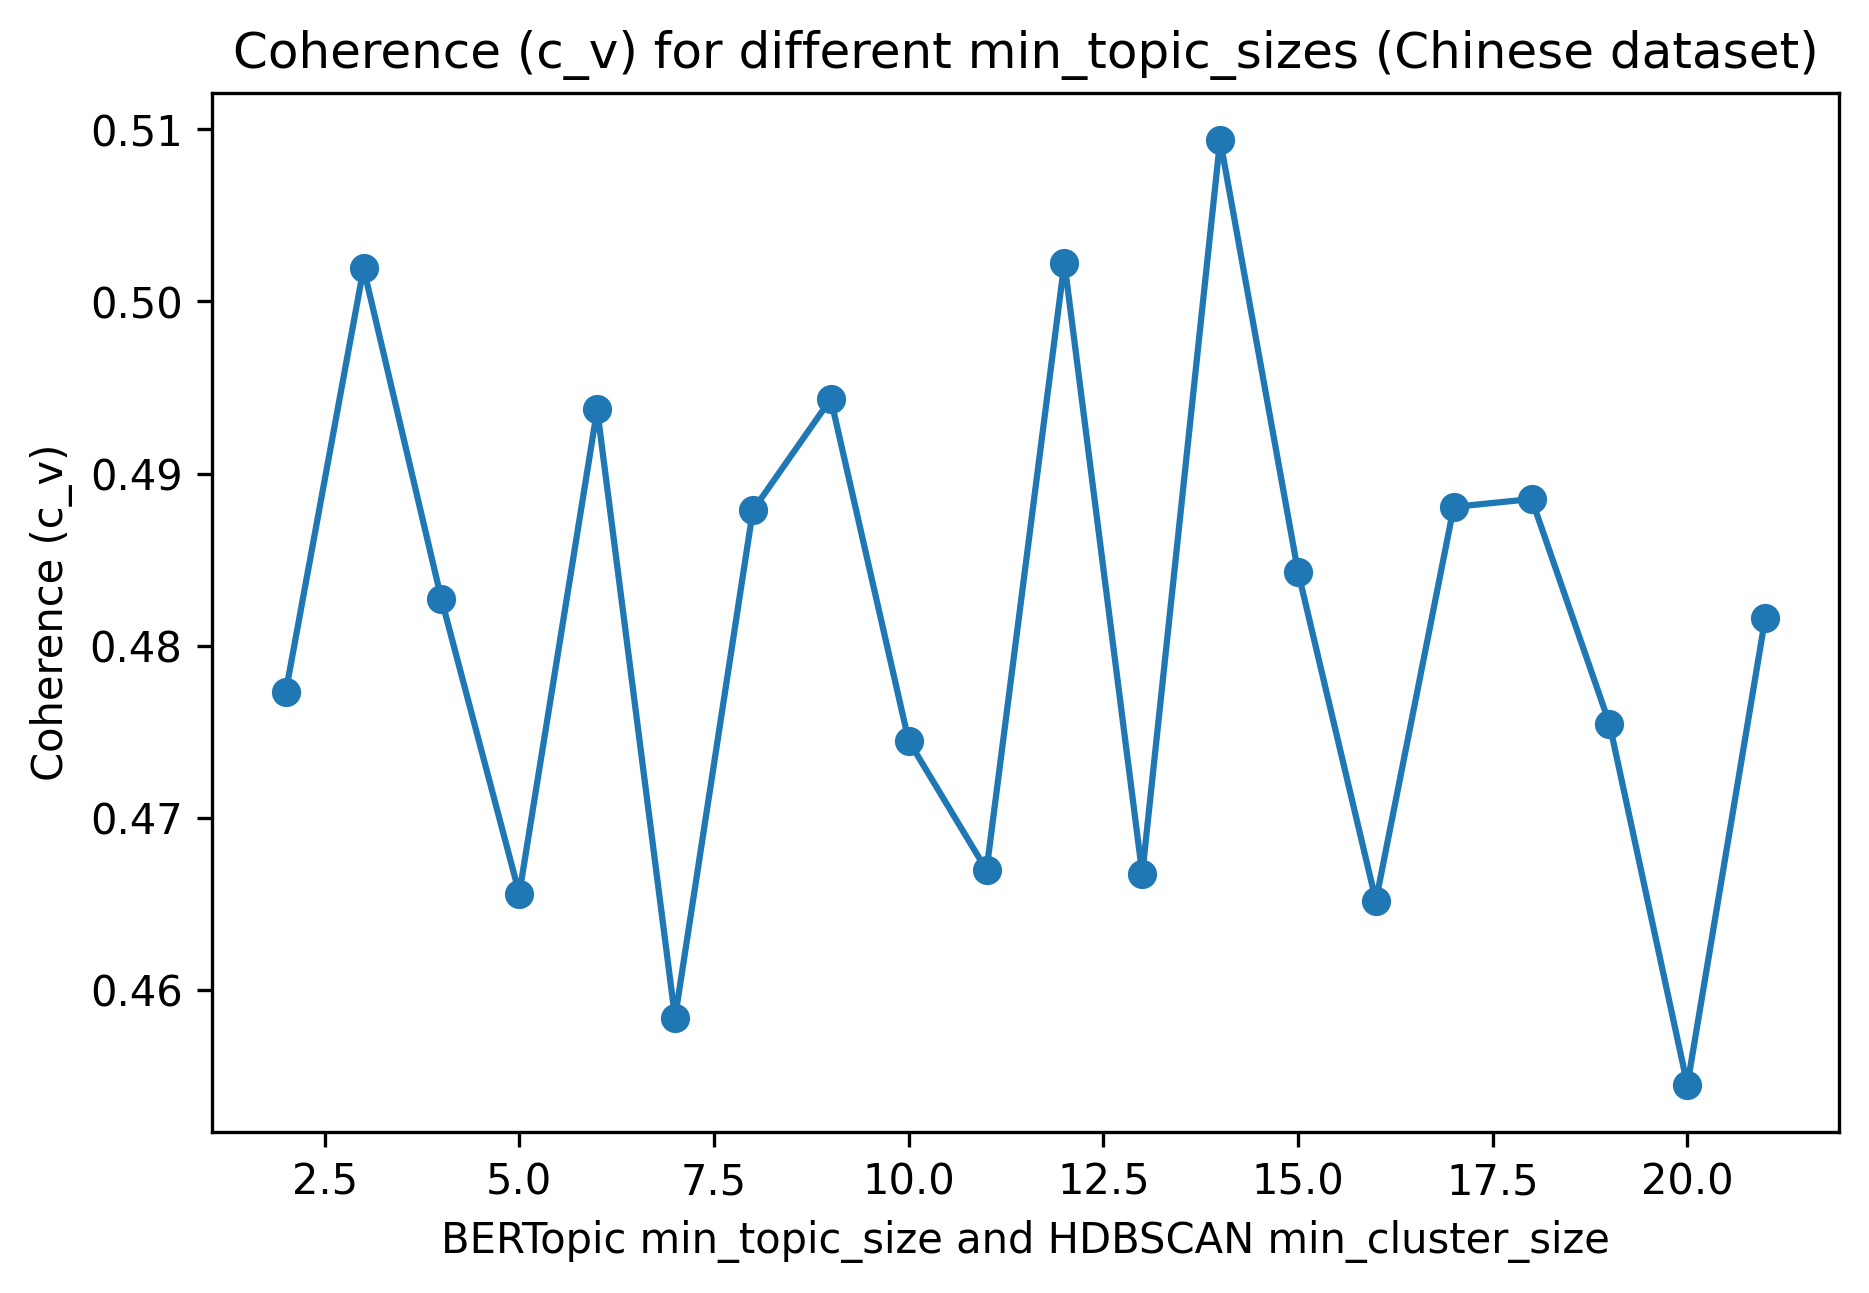

In [ ]:
# Plot coherence vs min_topic_size
plt.figure(figsize=(7,4.5), dpi=300)
plt.plot(results["min_topic_size"], results["coherence_cv"], marker='o')
plt.title('Coherence (c_v) for different min_topic_sizes (Chinese dataset)')
plt.xlabel('BERTopic min_topic_size and HDBSCAN min_cluster_size')
plt.ylabel('Coherence (c_v)')
plt.grid(False)
plt.show()

## **LDA analysis for Chinese**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
def print_top_words(model, feature_names, n_top_words):
    tword = []
    for topic_idx, topic in enumerate(model.components_):
        print("Topic #%d:" % topic_idx)
        topic_w = " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        tword.append(topic_w)
        print(topic_w)
    return tword

In [ ]:
n_features = 1500     # extract 1500 features
tf_vectorizer = CountVectorizer(strip_accents = 'unicode',
                    max_features=n_features,
                    stop_words='english',
                    max_df = 0.5,
                    min_df = 10)
tf = tf_vectorizer.fit_transform(Chinese_df.Chinese_cutted)

In [ ]:
# perplexity curve

plexs = []
scores = []
n_max_topics = 20
for i in range(1, n_max_topics):
    print('This is the epoch: ',i)
    lda = LatentDirichletAllocation(n_components=i, max_iter=50,
                                    learning_method='batch',
                                    learning_offset=50,random_state=0)
    lda.fit(tf)
    plexs.append(lda.perplexity(tf))
    scores.append(lda.score(tf))


This is the epoch:  1
This is the epoch:  2
This is the epoch:  3
This is the epoch:  4
This is the epoch:  5
This is the epoch:  6
This is the epoch:  7
This is the epoch:  8
This is the epoch:  9
This is the epoch:  10
This is the epoch:  11
This is the epoch:  12
This is the epoch:  13
This is the epoch:  14
This is the epoch:  15
This is the epoch:  16
This is the epoch:  17
This is the epoch:  18
This is the epoch:  19


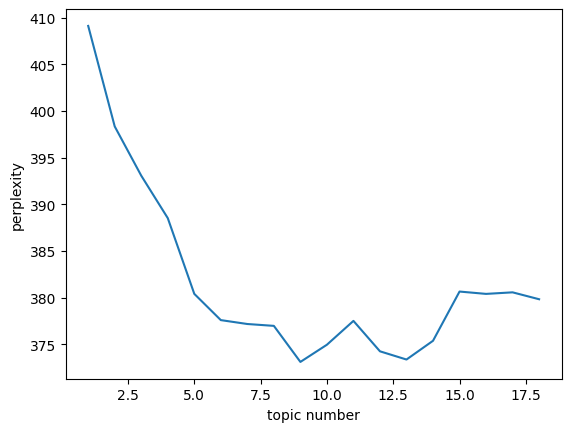

In [ ]:
n_t = 19         # set the range in x-axis
x = list(range(1,n_t))
plt.plot(x, plexs[1: n_t])
plt.xlabel("topic number")
plt.ylabel("perplexity")
plt.savefig("/content/perplexity.png", format="png", bbox_inches="tight")

# display the figure
plt.show()

In [ ]:
tokenized_docs = Chinese_df["Chinese_cutted"].astype(str).str.split()

K = 8
lda = LatentDirichletAllocation(
    n_components=K,
    learning_method="batch",
    random_state=42,
    max_iter=50,
)
lda.fit(tf)

n_top_words = 25
feature_names = np.array(tf_vectorizer.get_feature_names_out())

topics = []
for k in range(K):
    top_idx = np.argsort(lda.components_[k])[::-1][:n_top_words]
    topics.append(feature_names[top_idx].tolist())

# build dictionary for coherence
dictionary = Dictionary(tokenized_docs)

# compute coherence (c_v)
cm = CoherenceModel(
    topics=topics,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)
coh_overall = cm.get_coherence()
coh_per_topic = cm.get_coherence_per_topic()

print(f"Overall topic coherence (c_v): {coh_overall:.4f}")
for i, c in enumerate(coh_per_topic):
    print(f"Topic {i:02d} coherence (c_v): {c:.4f}")


# bootstrap 95% CI for overall coherence.
rng = np.random.default_rng(42)

B = 100  # number of bootstrap resamples
N = len(tokenized_docs)

boot_scores = []
for _ in range(B):
    idx = rng.integers(low=0, high=N, size=N)
    boot_texts = [tokenized_docs[i] for i in idx]

    boot_cm = CoherenceModel(
        topics=topics,
        texts=boot_texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    boot_scores.append(boot_cm.get_coherence())

boot_scores = np.array(boot_scores)
ci_low, ci_high = np.percentile(boot_scores, [2.5, 97.5])

print(f"\nBootstrap 95% CI for overall c_v: [{ci_low:.4f}, {ci_high:.4f}] (B={B})")
print(f"Bootstrap mean c_v: {boot_scores.mean():.4f}, std: {boot_scores.std(ddof=1):.4f}")

Overall topic coherence (c_v): 0.3883
Topic 00 coherence (c_v): 0.4205
Topic 01 coherence (c_v): 0.3521
Topic 02 coherence (c_v): 0.4143
Topic 03 coherence (c_v): 0.3769
Topic 04 coherence (c_v): 0.2912
Topic 05 coherence (c_v): 0.4583
Topic 06 coherence (c_v): 0.4266
Topic 07 coherence (c_v): 0.3668

Bootstrap 95% CI for overall c_v: [0.3316, 0.3873] (B=100)
Bootstrap mean c_v: 0.3597, std: 0.0139


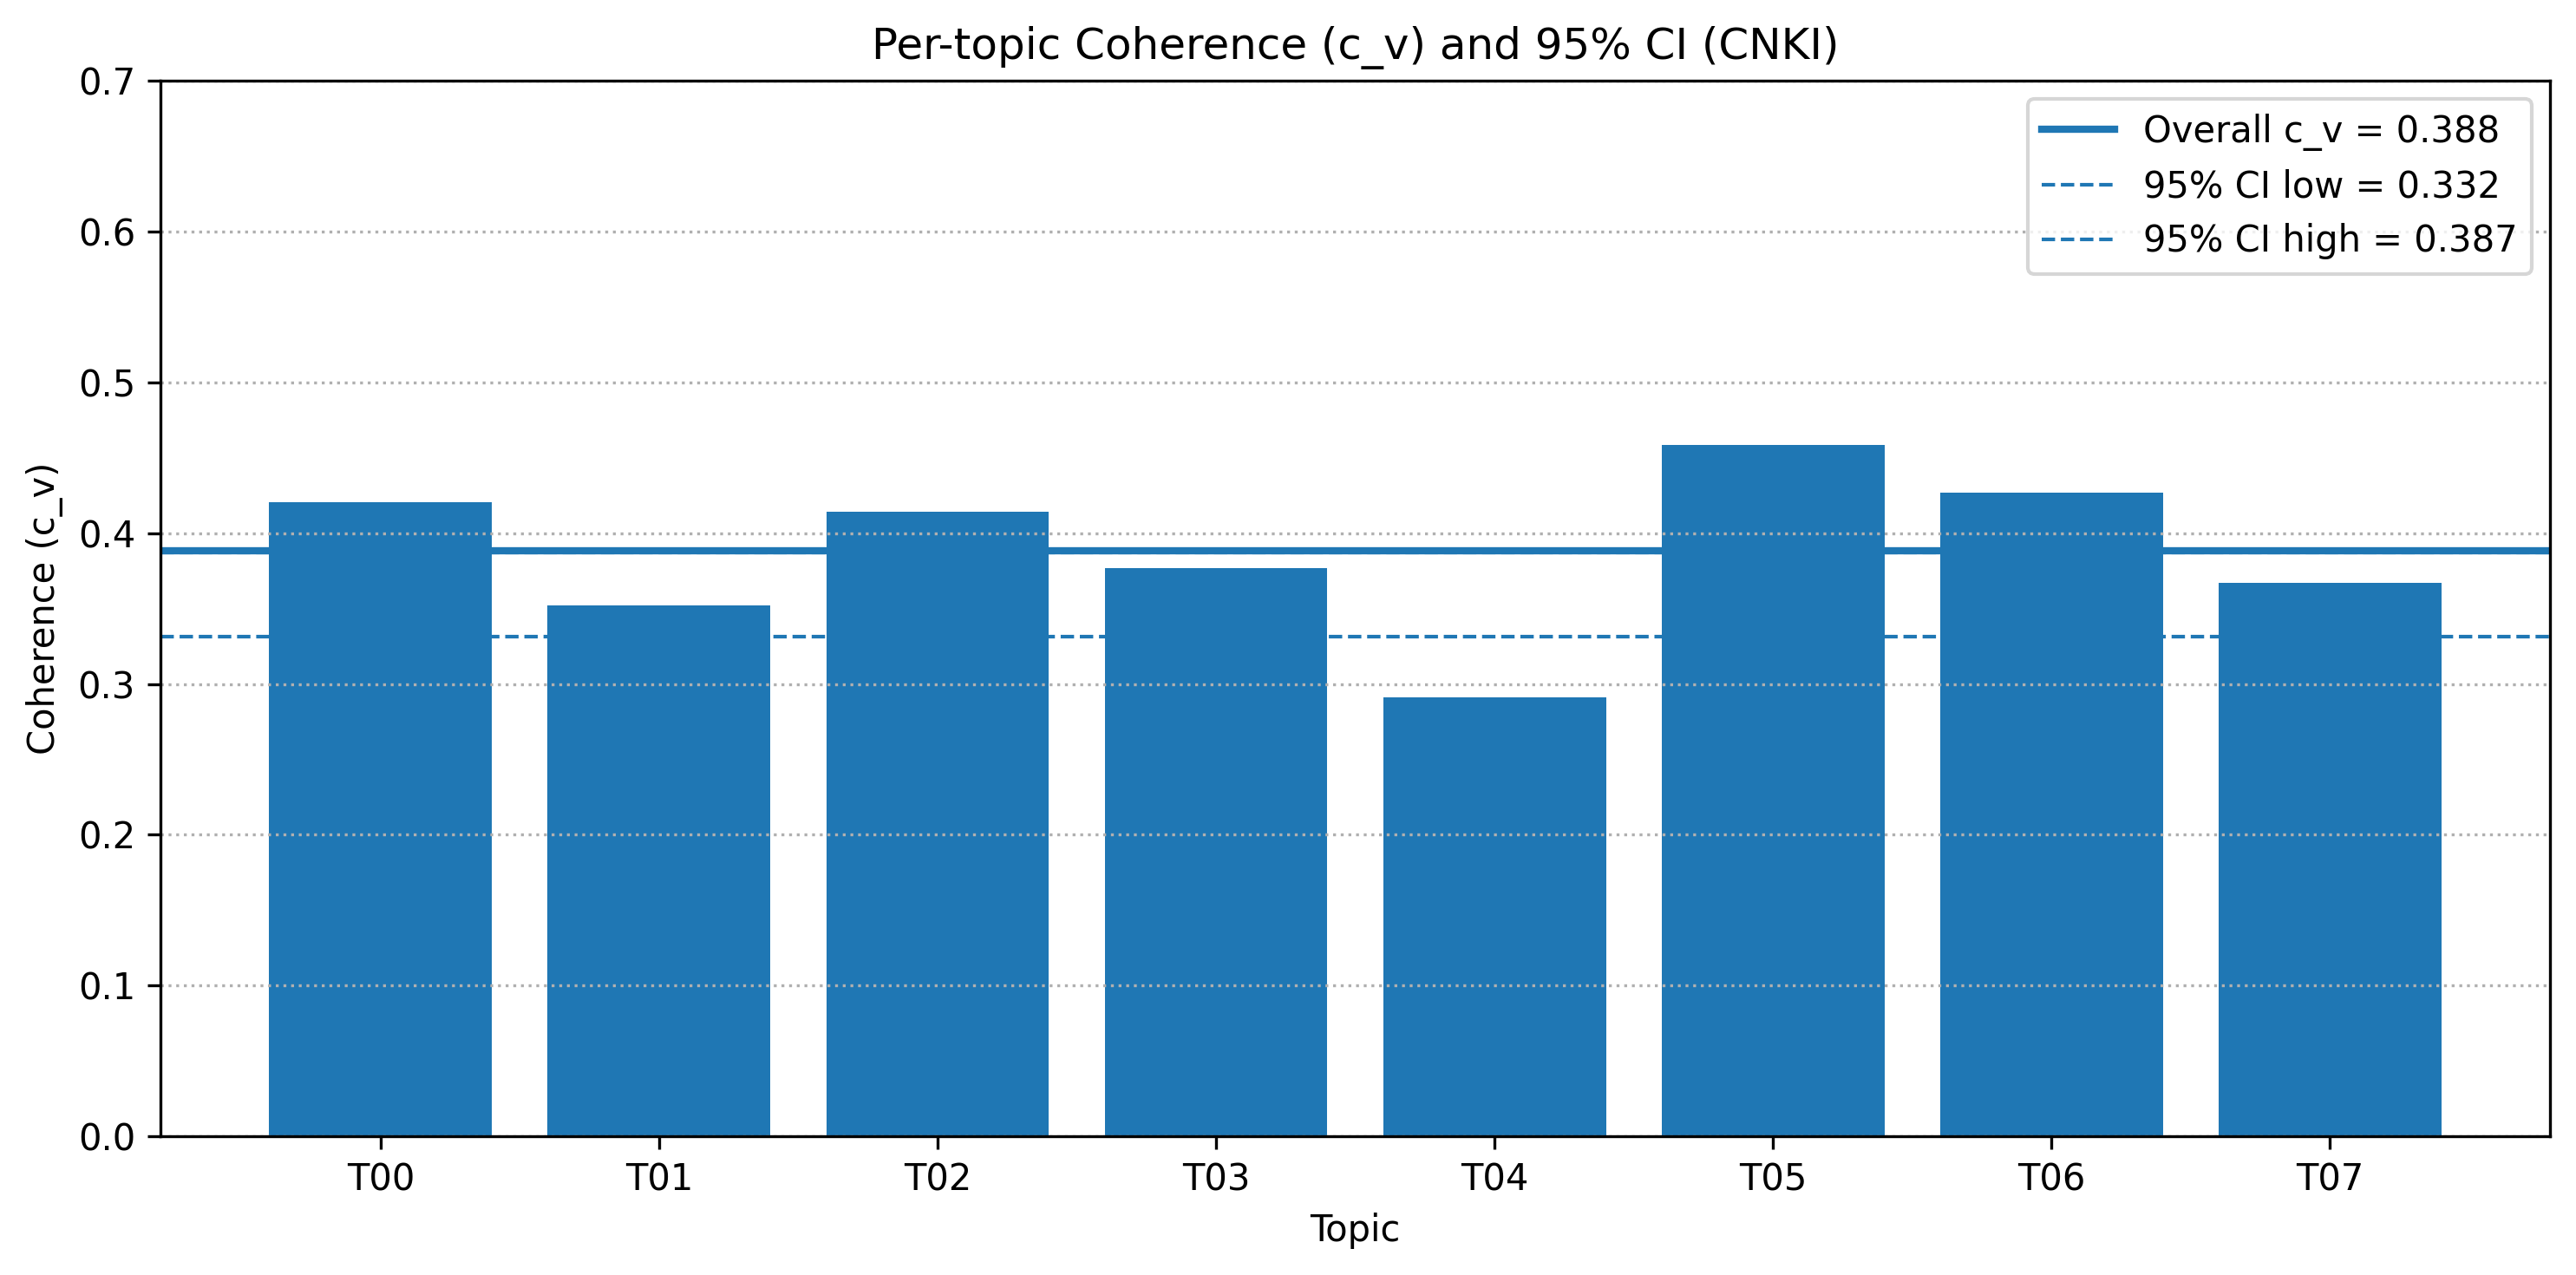

In [ ]:
# x-axis labels like T00, T01, ...
x = np.arange(K)
labels = [f"T{t:02d}" for t in x]
y = np.array(coh_per_topic)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# bar chart of per-topic coherence
ax.bar(x, y)

# overall coherence line
ax.axhline(coh_overall, linestyle='-', linewidth=2, label=f"Overall c_v = {coh_overall:.3f}")

# 95% CI lines
ax.axhline(ci_low, linestyle='--', linewidth=1, label=f"95% CI low = {ci_low:.3f}")
ax.axhline(ci_high, linestyle='--', linewidth=1, label=f"95% CI high = {ci_high:.3f}")

# niceties
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Coherence (c_v)")
ax.set_xlabel("Topic")
ax.set_title("Per-topic Coherence (c_v) and 95% CI (CNKI)")
ax.set_ylim(0, max(0.7, y.max() + 0.05))  # small headroom
ax.legend(loc="best")
ax.grid(axis='y', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()
